In [1]:
import pandas as pd
df = pd.read_csv("../data/processed/Telco-Customer-Churn-Clean.csv")

In [2]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [3]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
df.shape

(7043, 21)

In [5]:
import pandas as pd
from sqlalchemy import create_engine

In [11]:
username = "root"
password = "3306"
host = "127.0.0.1"
database = "customer_churn_db"
port = 3306
engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}")

In [39]:
df.to_sql(
    name = "telco_customer",
    con = engine,
    if_exists = "append",
    index = False
)

-1

In [19]:
query = "SELECT * FROM telco_customer"
df = pd.read_sql(query, engine)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [33]:
import warnings
warnings.filterwarnings("ignore")

df.describe(include = "object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,0002-ORFBO,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [35]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [37]:
df["customerID"].duplicated().sum()

np.int64(0)

In [39]:
num_cols = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include = "object").columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## Univariate Analysis

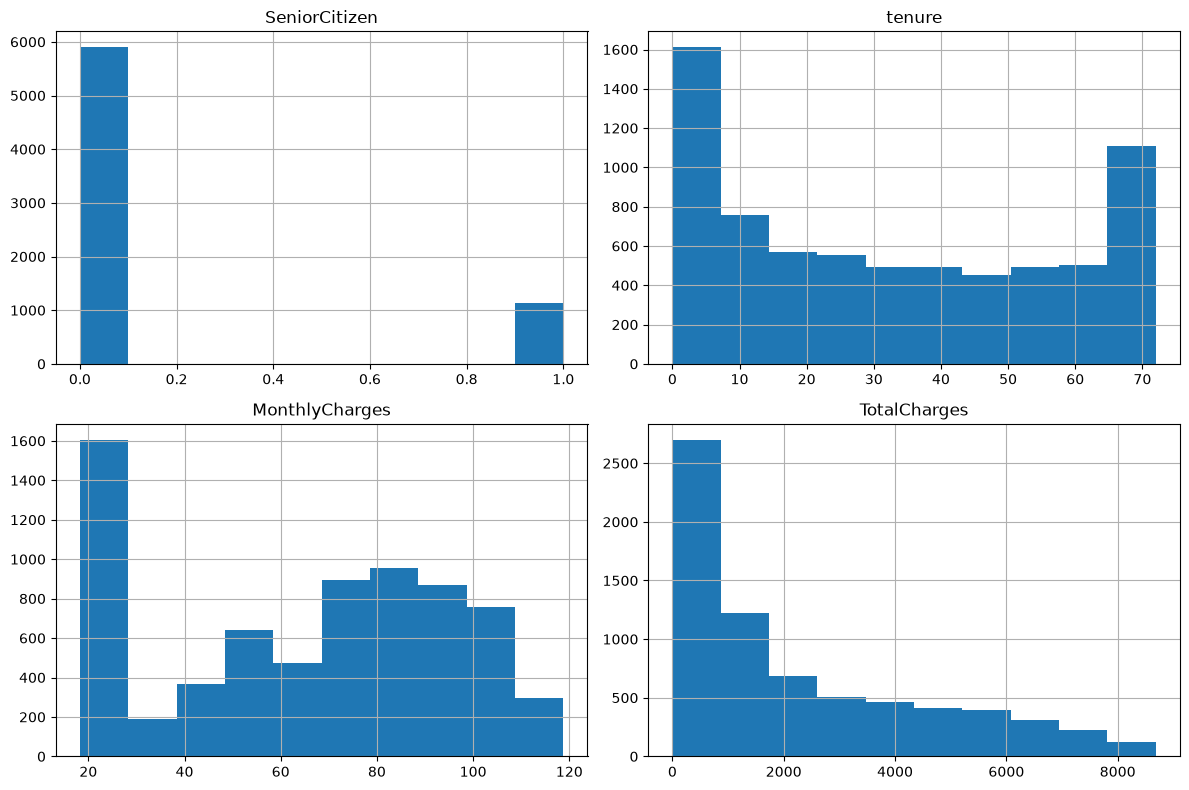

In [49]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize = (12, 8))
plt.tight_layout()
plt.show()

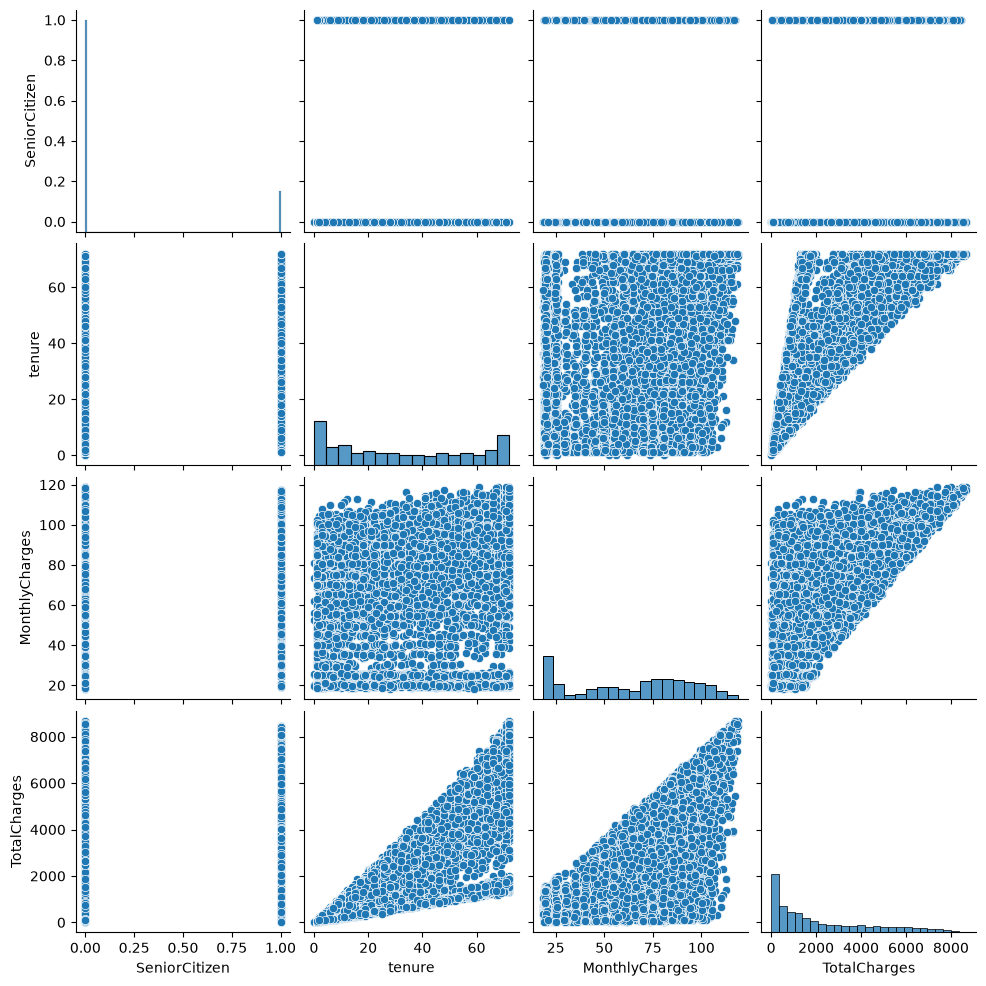

In [59]:
import seaborn as sns

sns.pairplot(df[num_cols])

## Categorical Analysis

In [53]:
for col in cat_cols:
    print("="*50)
    print(col)
    print(df[col].value_counts())

customerID
customerID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7043, dtype: int64
gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No intern

In [55]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [57]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize = "index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [61]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize = "index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [89]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], margins=True, margins_name="Total")

Churn,No,Yes,Total
SeniorCitizen,,,
0,4508,1393,5901
1,666,476,1142
Total,5174,1869,7043


In [91]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [93]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


## Churn vs Nemerical Variables

<Figure size 600x400 with 0 Axes>

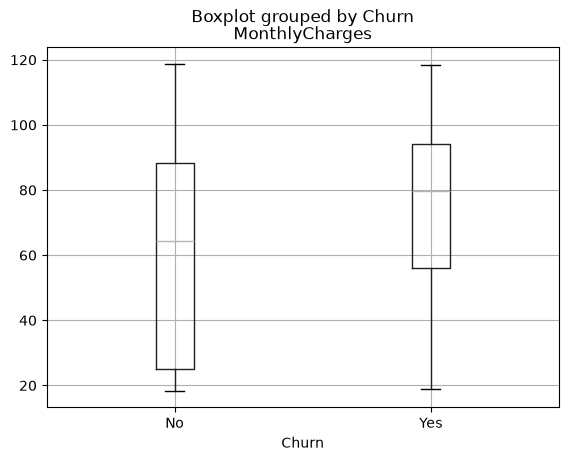

In [79]:
plt.figure(figsize = (6, 4))
df.boxplot(column = "MonthlyCharges", by = "Churn")
plt.show()

<Figure size 600x400 with 0 Axes>

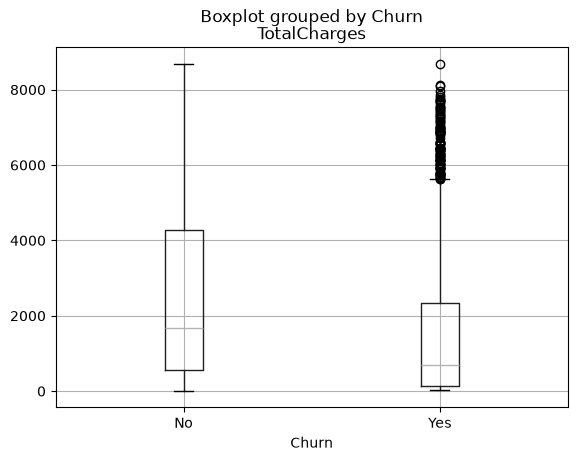

In [66]:
plt.figure(figsize = (6, 4))
df.boxplot(column = "TotalCharges", by = "Churn")
plt.show()

<Figure size 600x400 with 0 Axes>

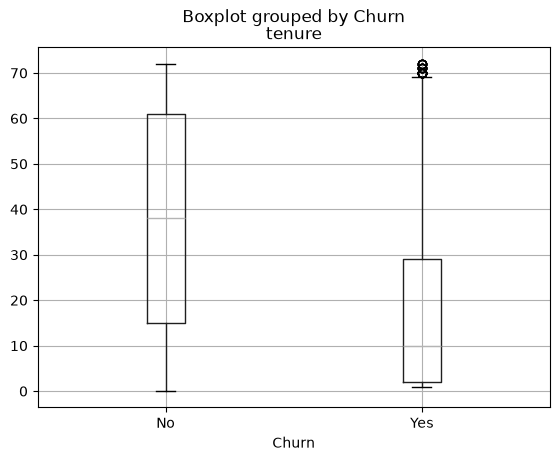

In [68]:
plt.figure(figsize = (6, 4))
df.boxplot(column = "tenure", by = "Churn")
plt.show()

## Correlation

In [73]:
corr_df = df.copy()
corr_df["Churn"] = corr_df["Churn"].map({"No": 0, "Yes": 1})

In [75]:
corr_df[
    ["SeniorCitizen",
     "tenure",
     "MonthlyCharges",
     "TotalCharges",
     "Churn"]
].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
Churn,0.150889,-0.352229,0.193356,-0.198324,1.000000


## Heatmap

<Axes: >

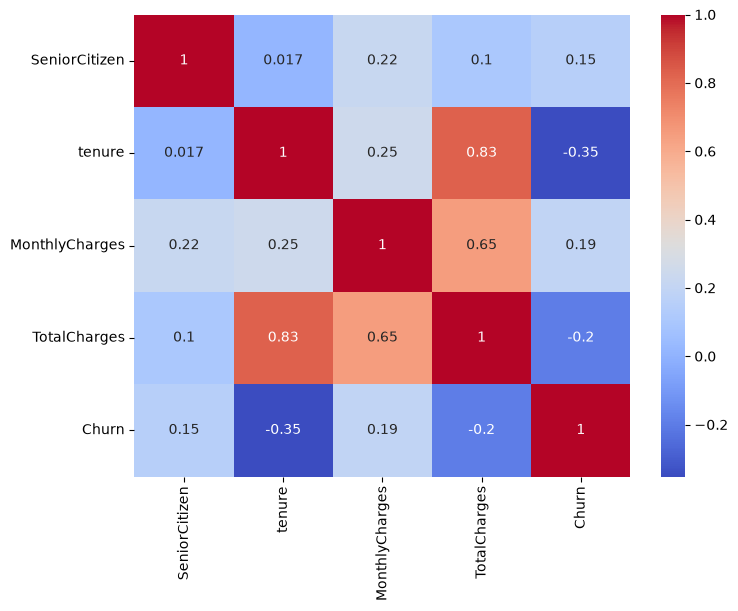

In [83]:
plt.figure(figsize = (8, 6))
sns.heatmap(
    corr_df[
    ["SeniorCitizen",
     "tenure",
     "MonthlyCharges",
     "TotalCharges",
     "Churn"]
    ].corr(), 
    annot = True,
    annot_kws = {"size": 10},
    cmap = "coolwarm"
)

# Churn by Tenure Group

In [99]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12",
    "13-24",
    "25-36",
    "37-48",
    "49-60",
    "61-72"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins = bins,
    labels = labels,
    include_lowest = True
)

pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize = "index"
) * 100

Churn,No,Yes
TenureGroup,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-36,78.365385,21.634615
37-48,80.971129,19.028871
49-60,85.576923,14.423077
61-72,93.390192,6.609808


In [101]:
df["TenureGroup"]

0        0-12
1        0-12
2        0-12
3       13-24
4        0-12
        ...  
7038    13-24
7039    13-24
7040     0-12
7041    61-72
7042    61-72
Name: TenureGroup, Length: 7043, dtype: category
Categories (6, str): ['0-12' < '13-24' < '25-36' < '37-48' < '49-60' < '61-72']

In [107]:
df["tenure"].min()

np.int64(0)